# Financial Performance Analysis Dashboard
Business Problem

Companies generate thousands of sales transactions every year. However, management needs meaningful insights rather than raw data. This project analyzes the company's financial and operational performance to identify revenue trends, profitability drivers, customer behavior, and regional performance. The findings will support strategic decision-making and improve overall business performance.

# Project Objectives

The analysis aims to answer the following questions:

How has revenue and profit changed over time?

Which products, customers, and regions contribute the most to revenue and profit?

Which operational factors (discounts, shipping costs, customer segments, etc.) affect profitability?

What recommendations can improve the company's financial performance?

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Load dataset
df = pd.read_csv(r"C:\Users\georg\OneDrive\Desktop\PoweBI practice\global_ecommerce_sales.csv")

# Display first five rows
df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,1/2/2023,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,1/2/2023,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,1/3/2023,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,1/3/2023,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,1/5/2023,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [6]:
df.shape

(2000, 15)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   object 
 1   Order_Date        2000 non-null   object 
 2   Customer_Name     2000 non-null   object 
 3   Customer_Segment  2000 non-null   object 
 4   Country           2000 non-null   object 
 5   Region            2000 non-null   object 
 6   Product_Category  2000 non-null   object 
 7   Product_Name      2000 non-null   object 
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 234.5+ KB


In [8]:
df.tail()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
1995,ORD-10823,12/31/2025,Linda Nilsson,Consumer,France,Europe,Furniture,Folding Table Portable,5,104.73,0,523.65,19.10,190.36,PayPal
1996,ORD-10896,12/31/2025,Ayumi Dubois,Consumer,France,Europe,Clothing & Accessories,Cotton Formal Shirt,11,59.27,5,619.37,20.94,272.44,PayPal
1997,ORD-11148,12/31/2025,Barbara Jones,Consumer,Spain,Europe,Technology,Webcam HD 1080p,6,31.79,15,162.13,15.19,42.03,Bank Transfer
1998,ORD-11519,12/31/2025,Maria Suzuki,Home Office,Spain,Europe,Clothing & Accessories,Sports Water Bottle 750ml,5,9.50,5,45.12,14.25,7.12,Credit Card
1999,ORD-11701,12/31/2025,Susan Russo,Home Office,South Korea,Asia Pacific,Clothing & Accessories,Sports Water Bottle 750ml,11,28.27,0,310.97,36.23,119.26,Credit Card


In [9]:
df.describe()

,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,3.56,73.33,8.57,242.28,12.90,79.44
std,2.70,79.31,7.26,382.58,5.22,137.57
min,1.00,3.03,0.00,2.42,5.52,-11.28
25%,2.00,18.76,0.00,41.23,9.46,6.87
50%,3.00,46.42,10.00,113.12,11.84,32.83
75%,5.00,90.25,15.00,266.55,14.92,90.30
max,15.00,472.56,30.00,3813.98,40.44,1373.63


In [10]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment',
       'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity',
       'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost',
       'Profit', 'Payment_Method'],
      dtype='object')

In [17]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Country             0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Total_Sales         0
Shipping_Cost       0
Profit              0
Payment_Method      0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.nunique()

Order_ID            2000
Order_Date           907
Customer_Name       1534
Customer_Segment       3
Country               20
Region                 5
Product_Category       4
Product_Name          40
Quantity              15
Unit_Price          1839
Discount_Percent       7
Total_Sales         1927
Shipping_Cost       1118
Profit              1855
Payment_Method         4
dtype: int64

In [12]:
df.dtypes

Order_ID             object
Order_Date           object
Customer_Name        object
Customer_Segment     object
Country              object
Region               object
Product_Category     object
Product_Name         object
Quantity              int64
Unit_Price          float64
Discount_Percent      int64
Total_Sales         float64
Shipping_Cost       float64
Profit              float64
Payment_Method       object
dtype: object

In [15]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Date'].dtype

dtype('<M8[ns]')

In [16]:
print("Earliest Order:", df['Order_Date'].min())
print("Latest Order:", df['Order_Date'].max())

Earliest Order: 2023-01-02 00:00:00
Latest Order: 2025-12-31 00:00:00


In [20]:
#convert order date
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2000 non-null   object        
 1   Order_Date        2000 non-null   datetime64[ns]
 2   Customer_Name     2000 non-null   object        
 3   Customer_Segment  2000 non-null   object        
 4   Country           2000 non-null   object        
 5   Region            2000 non-null   object        
 6   Product_Category  2000 non-null   object        
 7   Product_Name      2000 non-null   object        
 8   Quantity          2000 non-null   int64         
 9   Unit_Price        2000 non-null   float64       
 10  Discount_Percent  2000 non-null   int64         
 11  Total_Sales       2000 non-null   float64       
 12  Shipping_Cost     2000 non-null   float64       
 13  Profit            2000 non-null   float64       
 14  Payment_Method    2000 n

In [23]:
df[['Quantity','Unit_Price','Total_Sales','Shipping_Cost','Profit']].describe()

,Quantity,Unit_Price,Total_Sales,Shipping_Cost,Profit
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,3.56,73.33,242.28,12.90,79.44
std,2.70,79.31,382.58,5.22,137.57
min,1.00,3.03,2.42,5.52,-11.28
25%,2.00,18.76,41.23,9.46,6.87
50%,3.00,46.42,113.12,11.84,32.83
75%,5.00,90.25,266.55,14.92,90.30
max,15.00,472.56,3813.98,40.44,1373.63


In [24]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

df.columns

Index(['order_id', 'order_date', 'customer_name', 'customer_segment',
       'country', 'region', 'product_category', 'product_name', 'quantity',
       'unit_price', 'discount_percent', 'total_sales', 'shipping_cost',
       'profit', 'payment_method'],
      dtype='object')

In [25]:
df['year'] = df['order_date'].dt.year

In [26]:
df['month'] = df['order_date'].dt.month_name()

In [27]:
df['month_number'] = df['order_date'].dt.month

In [28]:
df['quarter'] = df['order_date'].dt.quarter

In [29]:
#profit margin
df['profit_margin'] = (
    df['profit'] / df['total_sales']
) * 100

In [30]:
#cost
df['cost'] = df['total_sales'] - df['profit']

In [31]:
df.head()

,order_id,order_date,customer_name,customer_segment,country,region,product_category,product_name,quantity,unit_price,discount_percent,total_sales,shipping_cost,profit,payment_method,year,month,month_number,quarter,profit_margin,cost
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery,2023,January,1,1,41.88,173.37
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery,2023,January,1,1,26.68,229.76
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card,2023,January,1,1,17.18,17.79
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal,2023,January,1,1,25.03,78.84
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card,2023,January,1,1,23.95,804.70


In [32]:
df.to_csv(
    "financial_analysis_cleaned.csv",
    index=False
)

# EDA
# 1.How has revenue and profit changed overtime?

In [33]:
#overall financial performance
total_sales = df['total_sales'].sum()
total_profit = df['profit'].sum()
total_cost = df['cost'].sum()
total_orders = df['order_id'].nunique()

average_order_value = total_sales / total_orders

profit_margin = (total_profit / total_sales) * 100


print("Total Sales:", round(total_sales,2))
print("Total Profit:", round(total_profit,2))
print("Total Cost:", round(total_cost,2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value,2))
print("Profit Margin:", round(profit_margin,2), "%")

Total Sales: 484559.34
Total Profit: 158872.32
Total Cost: 325687.02
Total Orders: 2000
Average Order Value: 242.28
Profit Margin: 32.79 %


In [34]:
#yearly revenue analysis
yearly_sales = (
    df.groupby('year')
    ['total_sales']
    .sum()
    .reset_index()
)

yearly_sales

,year,total_sales
0,2023,164443.45
1,2024,155150.73
2,2025,164965.16


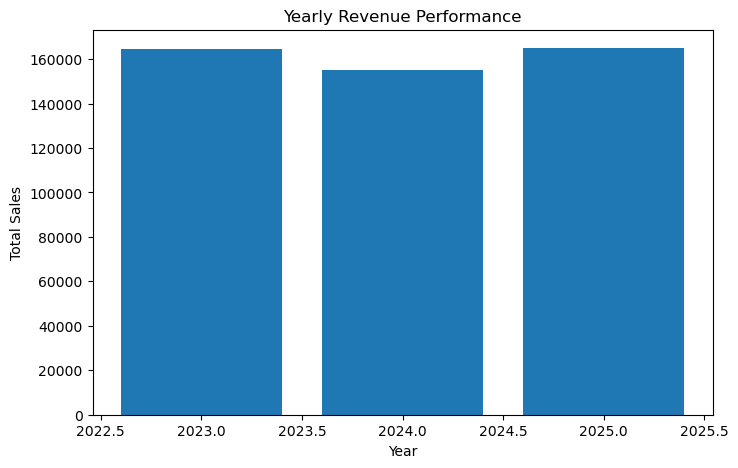

In [35]:
plt.figure(figsize=(8,5))

plt.bar(
    yearly_sales['year'],
    yearly_sales['total_sales']
)

plt.title("Yearly Revenue Performance")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

In [36]:
#yearly profit analysis
yearly_profit = (
    df.groupby('year')
    ['profit']
    .sum()
    .reset_index()
)

yearly_profit

,year,profit
0,2023,53153.74
1,2024,51616.11
2,2025,54102.47


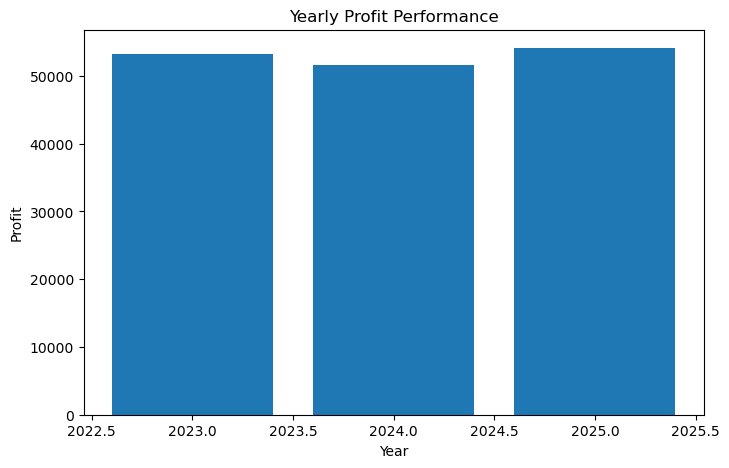

In [37]:
plt.figure(figsize=(8,5))

plt.bar(
    yearly_profit['year'],
    yearly_profit['profit']
)

plt.title("Yearly Profit Performance")
plt.xlabel("Year")
plt.ylabel("Profit")

plt.show()

In [38]:
#monthly revenue trend
monthly_sales = (
    df.groupby(
        ['year','month_number','month']
    )['total_sales']
    .sum()
    .reset_index()
)

monthly_sales.head()

,year,month_number,month,total_sales
0,2023,1,January,11275.20
1,2023,2,February,16943.67
2,2023,3,March,16056.45
3,2023,4,April,12185.00
4,2023,5,May,8218.47


In [39]:
monthly_sales = monthly_sales.sort_values(
    ['year','month_number']
)

monthly_sales.head()

,year,month_number,month,total_sales
0,2023,1,January,11275.20
1,2023,2,February,16943.67
2,2023,3,March,16056.45
3,2023,4,April,12185.00
4,2023,5,May,8218.47


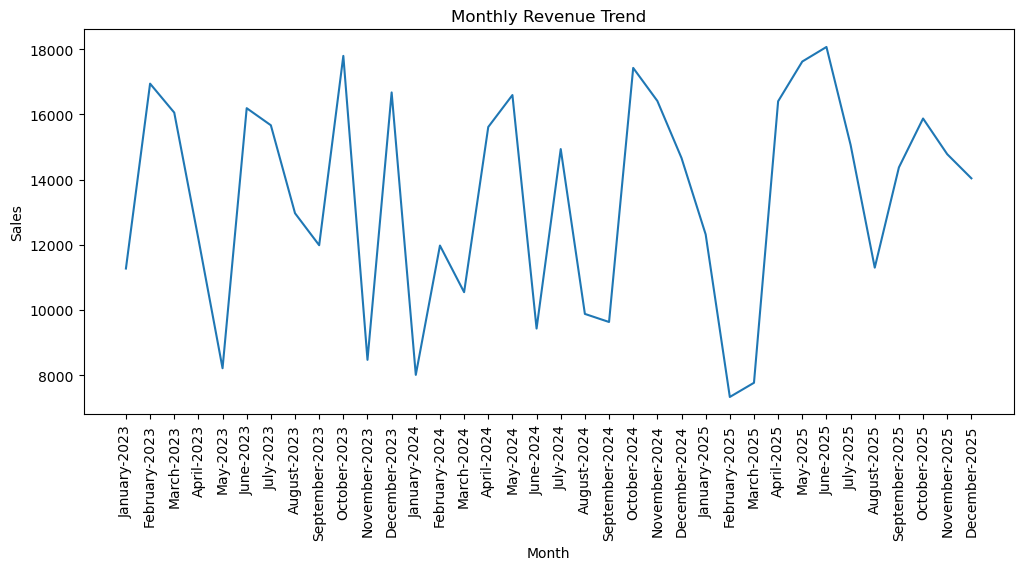

In [40]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales['month'] + "-" + monthly_sales['year'].astype(str),
    monthly_sales['total_sales']
)

plt.xticks(rotation=90)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [41]:
#monthly profit trend
monthly_profit = (
    df.groupby(
        ['year','month_number','month']
    )['profit']
    .sum()
    .reset_index()
)

monthly_profit = monthly_profit.sort_values(
    ['year','month_number']
)

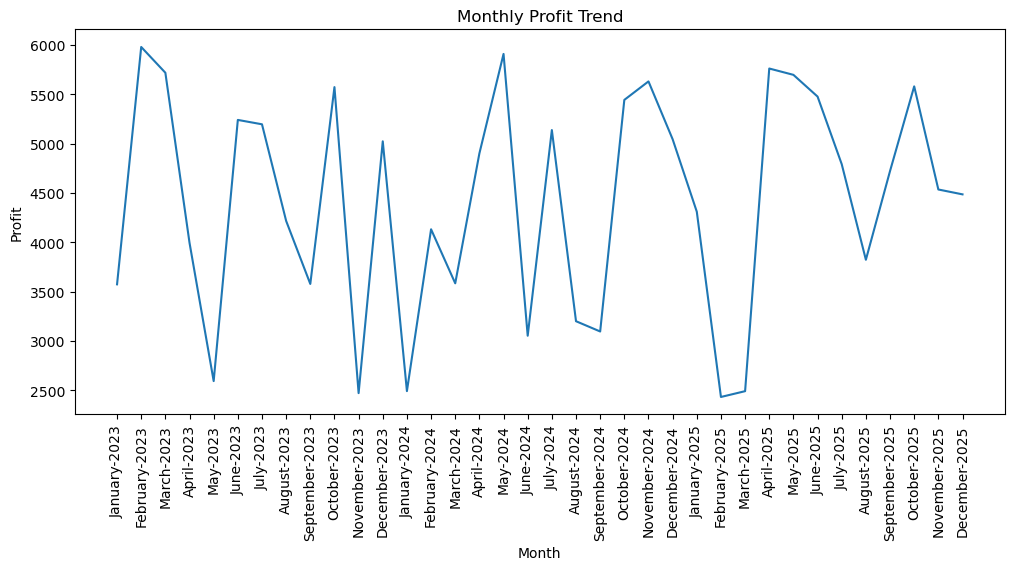

In [42]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_profit['month'] + "-" + monthly_profit['year'].astype(str),
    monthly_profit['profit']
)

plt.xticks(rotation=90)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.show()

In [45]:
print("Total Sales:", round(total_sales,2))
...

Total Sales: 484559.34


In [46]:
yearly_sales

,year,total_sales
0,2023,164443.45
1,2024,155150.73
2,2025,164965.16


In [51]:
yearly_sales['growth_%'] = yearly_sales['total_sales'].pct_change() * 100
yearly_sales

,year,total_sales,growth_%
0,2023,164443.45,NaN
1,2024,155150.73,-5.65
2,2025,164965.16,6.33


In [47]:
yearly_profit

,year,profit
0,2023,53153.74
1,2024,51616.11
2,2025,54102.47


In [52]:
yearly_profit['growth_%'] = yearly_profit['profit'].pct_change() * 100
yearly_profit

,year,profit,growth_%
0,2023,53153.74,NaN
1,2024,51616.11,-2.89
2,2025,54102.47,4.82


In [48]:
monthly_sales

,year,month_number,month,total_sales
0,2023,1,January,11275.20
1,2023,2,February,16943.67
2,2023,3,March,16056.45
3,2023,4,April,12185.00
4,2023,5,May,8218.47
5,2023,6,June,16191.61
6,2023,7,July,15667.73
7,2023,8,August,12971.07
8,2023,9,September,11989.72
9,2023,10,October,17794.60


In [50]:
monthly_profit

,year,month_number,month,profit
0,2023,1,January,3573.01
1,2023,2,February,5980.06
2,2023,3,March,5718.77
3,2023,4,April,3994.25
4,2023,5,May,2591.86
5,2023,6,June,5240.34
6,2023,7,July,5195.97
7,2023,8,August,4216.32
8,2023,9,September,3577.00
9,2023,10,October,5573.05


In [53]:
monthly_sales['year_month'] = pd.to_datetime(
    monthly_sales['year'].astype(str) + '-' +
    monthly_sales['month_number'].astype(str) + '-01'
)

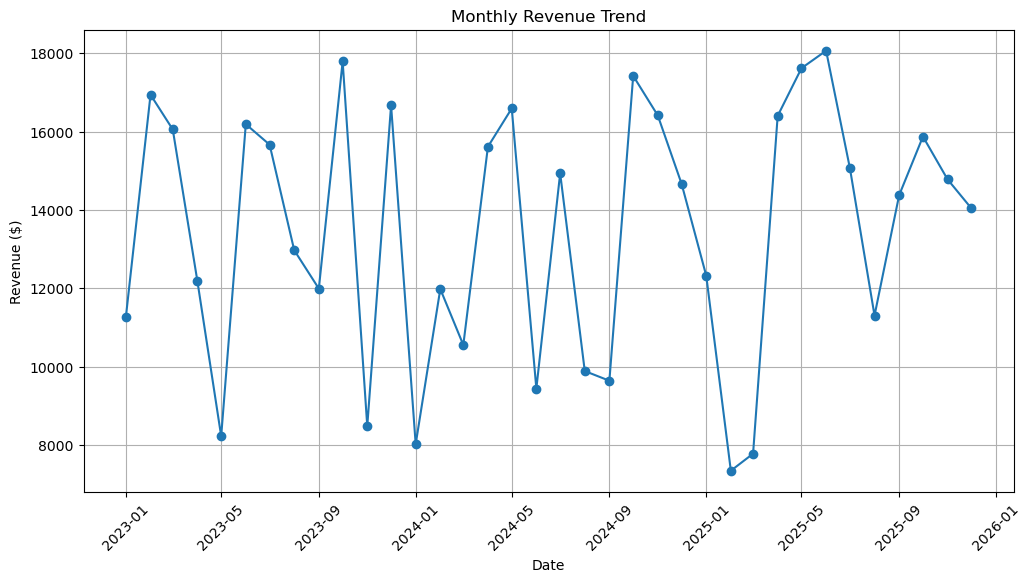

In [54]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['year_month'], monthly_sales['total_sales'], marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# 2.Which products, product categories, customers, and regions contribute the most to revenue and profit?

In [55]:
category_sales = (
    df.groupby('product_category')['total_sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_sales

,product_category,total_sales
0,Furniture,256274.68
1,Technology,139518.22
2,Clothing & Accessories,69375.63
3,Office Supplies,19390.81


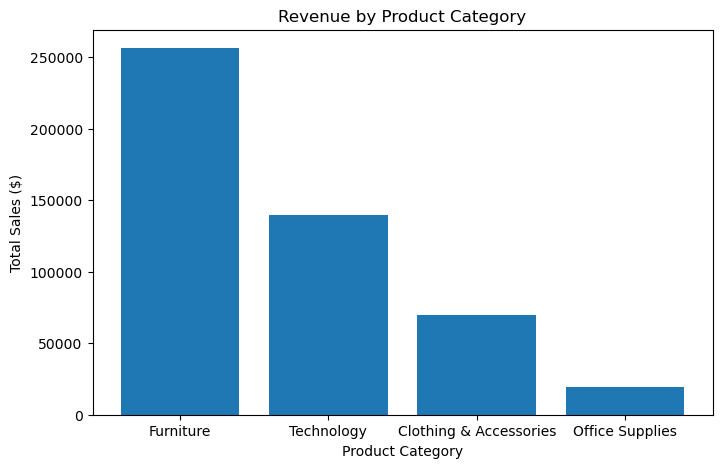

In [56]:
plt.figure(figsize=(8,5))

plt.bar(
    category_sales['product_category'],
    category_sales['total_sales']
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales ($)")

plt.show()

In [57]:
category_profit = (
    df.groupby('product_category')['profit']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_profit

,product_category,profit
0,Furniture,81171.57
1,Technology,48268.65
2,Clothing & Accessories,26112.94
3,Office Supplies,3319.16


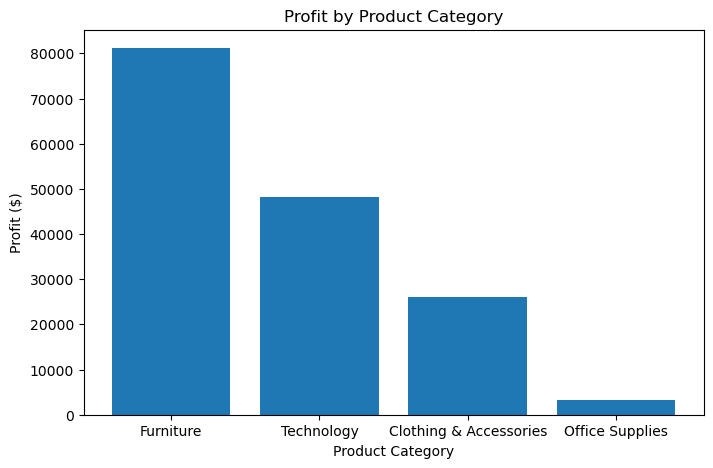

In [58]:
plt.figure(figsize=(8,5))

plt.bar(
    category_profit['product_category'],
    category_profit['profit']
)

plt.title("Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit ($)")

plt.show()

In [77]:
#profit margin by product category
category_margin = (
    df.groupby('product_category')
      .agg({
          'total_sales':'sum',
          'profit':'sum'
      })
)

category_margin['profit_margin'] = (
    category_margin['profit'] /
    category_margin['total_sales']
) * 100

category_margin = category_margin.sort_values(
    'profit_margin',
    ascending=False
)

category_margin

,total_sales,profit,profit_margin
product_category,,,
Clothing & Accessories,69375.63,26112.94,37.64
Technology,139518.22,48268.65,34.60
Furniture,256274.68,81171.57,31.67
Office Supplies,19390.81,3319.16,17.12


In [73]:
# Top 10 products by sales
top_products_sales = (
    df.groupby('product_name')['total_sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_products_sales

,product_name,total_sales
0,Standing Desk Converter,46614.22
1,Ergonomic Office Chair,45405.15
2,Corner L-Shaped Desk,41070.48
3,Mesh Back Task Chair,38179.77
4,Wireless Bluetooth Headphones,28258.70
5,Mechanical Gaming Keyboard,24072.42
6,Filing Cabinet 3-Drawer,23108.01
7,Folding Table Portable,18663.13
8,Portable External SSD 1TB,18065.30
9,Bookshelf 5-Tier,17741.59


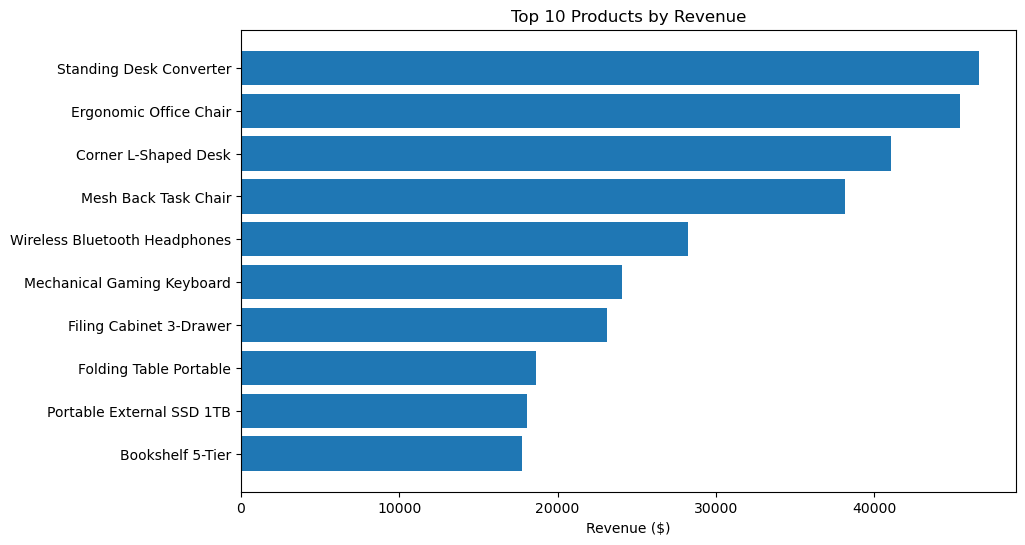

In [61]:
plt.figure(figsize=(10,6))

plt.barh(
    top_products_sales['product_name'],
    top_products_sales['total_sales']
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue ($)")
plt.gca().invert_yaxis()

plt.show()

In [71]:
#Top 10 products by profit
top_products_profit = (
    df.groupby('product_name')['profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_products_profit

,product_name,profit
0,Ergonomic Office Chair,15104.58
1,Standing Desk Converter,14694.35
2,Corner L-Shaped Desk,13663.00
3,Mesh Back Task Chair,12820.11
4,Wireless Bluetooth Headphones,10611.08
5,Mechanical Gaming Keyboard,8381.19
6,Filing Cabinet 3-Drawer,7041.80
7,Portable External SSD 1TB,6556.75
8,Business Casual Blazer,6004.33
9,Noise Cancelling Earbuds,5973.01


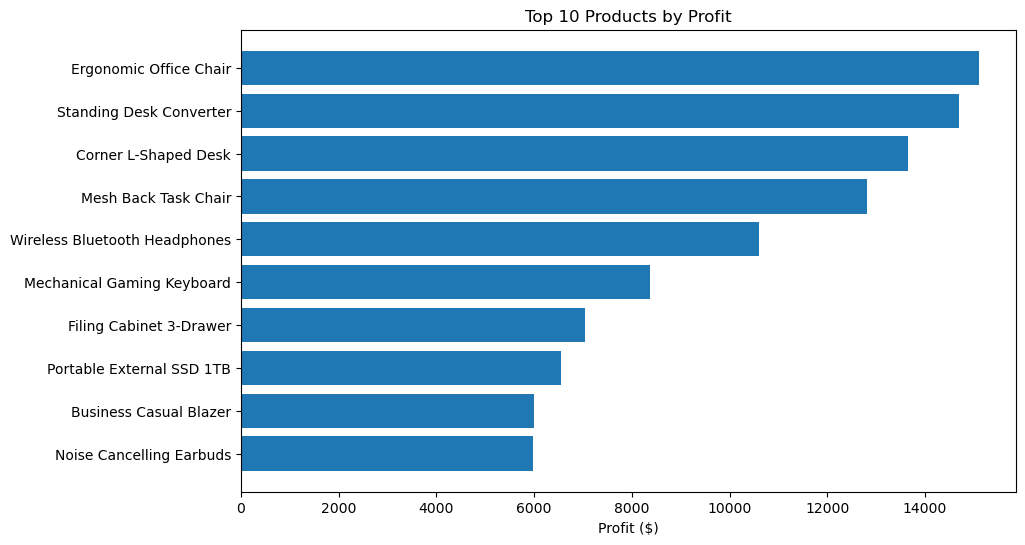

In [63]:
plt.figure(figsize=(10,6))

plt.barh(
    top_products_profit['product_name'],
    top_products_profit['profit']
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit ($)")
plt.gca().invert_yaxis()

plt.show()

In [70]:
#revenue by region
region_sales = (
    df.groupby('region')['total_sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

region_sales

,region,total_sales
0,Europe,137006.20
1,North America,133876.38
2,Asia Pacific,121707.51
3,South America,46051.13
4,Middle East & Africa,45918.12


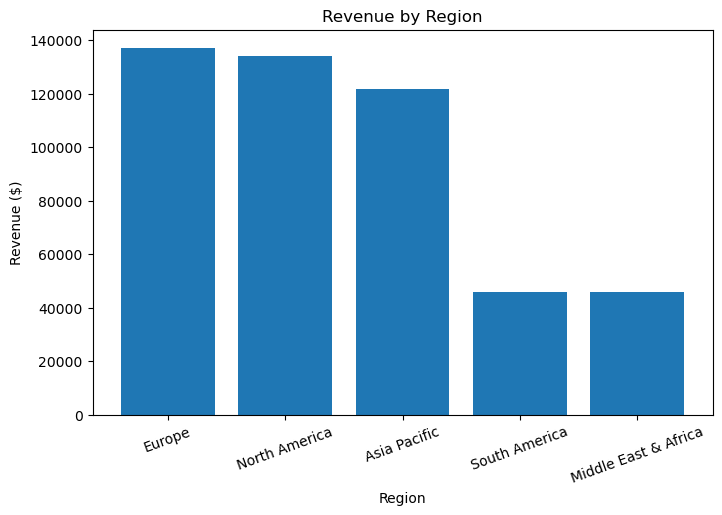

In [65]:
plt.figure(figsize=(8,5))

plt.bar(
    region_sales['region'],
    region_sales['total_sales']
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=20)

plt.show()

In [69]:
#profit by region
region_profit = (
    df.groupby('region')['profit']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

region_profit

,region,profit
0,Europe,45672.16
1,North America,45250.09
2,Asia Pacific,39116.61
3,South America,14680.98
4,Middle East & Africa,14152.48


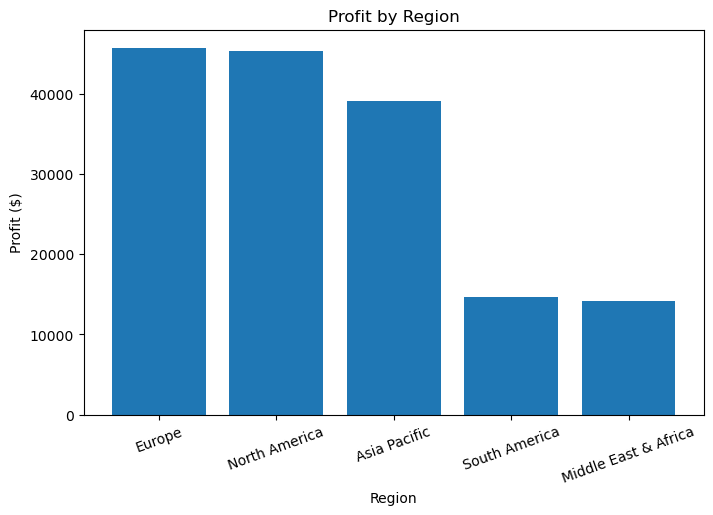

In [67]:
plt.figure(figsize=(8,5))

plt.bar(
    region_profit['region'],
    region_profit['profit']
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit ($)")
plt.xticks(rotation=20)

plt.show()

In [68]:
#revenue by customer segment
segment_sales = (
    df.groupby('customer_segment')['total_sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

segment_sales

,customer_segment,total_sales
0,Consumer,256287.74
1,Corporate,146050.39
2,Home Office,82221.21


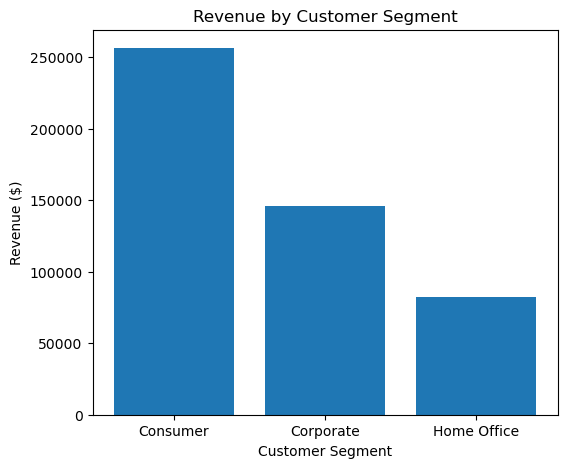

In [74]:
plt.figure(figsize=(6,5))

plt.bar(
    segment_sales['customer_segment'],
    segment_sales['total_sales']
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue ($)")

plt.show()

In [75]:
#Top 10 customers by revenue
top_customers = (
    df.groupby('customer_name')['total_sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_customers

,customer_name,total_sales
0,Priya Jackson,3836.46
1,Hanna Jones,3813.98
2,Sarah Chen,3184.56
3,Li Laurent,3007.62
4,Nadia Wang,2958.97
5,Priya Oliveira,2901.11
6,Felix Thompson,2835.36
7,Linda Weber,2762.40
8,Karen Sato,2738.18
9,Lucas Nilsson,2734.69


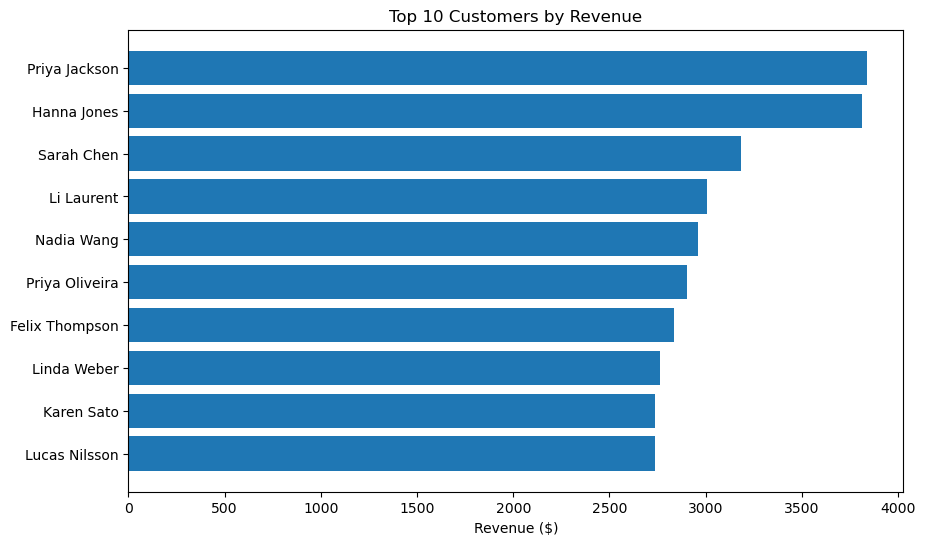

In [76]:
plt.figure(figsize=(10,6))

plt.barh(
    top_customers['customer_name'],
    top_customers['total_sales']
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue ($)")
plt.gca().invert_yaxis()

plt.show()

In [97]:
#all the analysis done above in QA 2
category_sales
category_profit
category_margin
region_sales
region_profit
segment_sales
top_products_sales.head(10)
top_customers.head(10)

,customer_name,total_sales
0,Priya Jackson,3836.46
1,Hanna Jones,3813.98
2,Sarah Chen,3184.56
3,Li Laurent,3007.62
4,Nadia Wang,2958.97
5,Priya Oliveira,2901.11
6,Felix Thompson,2835.36
7,Linda Weber,2762.40
8,Karen Sato,2738.18
9,Lucas Nilsson,2734.69


# 3.What expenses are affecting profitability the most?

In [87]:
#how discounts affect sales and profit
discount_analysis = (
    df.groupby('discount_percent')
      .agg({
          'total_sales':'sum',
          'profit':'sum',
          'order_id':'count'
      })
      .rename(columns={'order_id':'orders'})
      .reset_index()
)

discount_analysis

,discount_percent,total_sales,profit,orders
0,0,130966.22,50705.28,503
1,5,130452.23,46129.15,488
2,10,103136.11,32932.51,443
3,15,61074.44,16503.10,312
4,20,40229.76,9305.38,169
5,25,13272.27,2568.58,67
6,30,5428.31,728.32,18


In [88]:
#create profit margin by discount
discount_analysis['profit_margin'] = (
    discount_analysis['profit'] /
    discount_analysis['total_sales']
) * 100

discount_analysis

,discount_percent,total_sales,profit,orders,profit_margin
0,0,130966.22,50705.28,503,38.72
1,5,130452.23,46129.15,488,35.36
2,10,103136.11,32932.51,443,31.93
3,15,61074.44,16503.10,312,27.02
4,20,40229.76,9305.38,169,23.13
5,25,13272.27,2568.58,67,19.35
6,30,5428.31,728.32,18,13.42


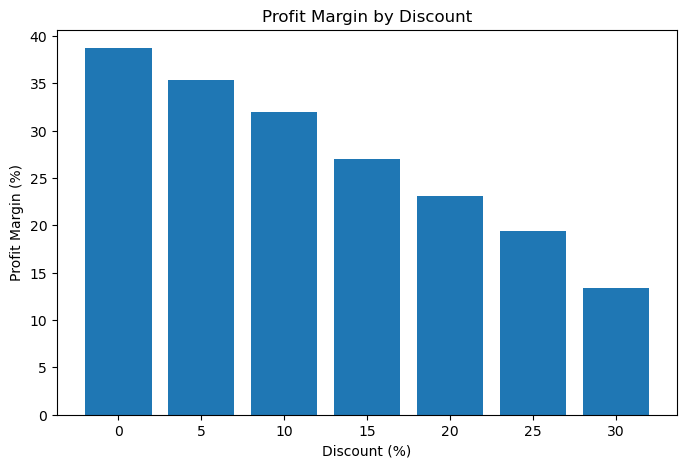

In [89]:
plt.figure(figsize=(8,5))

plt.bar(
    discount_analysis['discount_percent'].astype(str),
    discount_analysis['profit_margin']
)

plt.title("Profit Margin by Discount")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")

plt.show()

In [90]:
#shipping cost analysis
shipping_summary = (
    df[['shipping_cost']]
    .describe()
)

shipping_summary

,shipping_cost
count,2000.00
mean,12.90
std,5.22
min,5.52
25%,9.46
50%,11.84
75%,14.92
max,40.44


In [91]:
#shipping cost by region
shipping_region = (
    df.groupby('region')['shipping_cost']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

shipping_region

,region,shipping_cost
0,Middle East & Africa,16.00
1,South America,15.44
2,Asia Pacific,14.48
3,Europe,12.30
4,North America,10.05


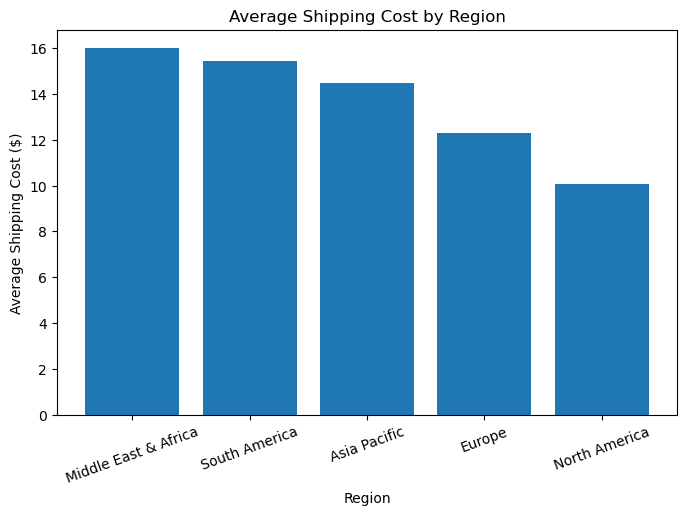

In [114]:
plt.figure(figsize=(8,5))

plt.bar(
    shipping_region['region'],
    shipping_region['shipping_cost']
)

plt.title("Average Shipping Cost by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Cost ($)")
plt.xticks(rotation=20)

plt.show()

In [113]:
# payment method analysis
payment_analysis = (
    df.groupby('payment_method')
      .agg({
          'total_sales':'sum',
          'profit':'sum',
          'order_id':'count'
      })
      .rename(columns={'order_id':'orders'})
      .reset_index()
)

payment_analysis

,payment_method,total_sales,profit,orders
0,Bank Transfer,71599.04,23555.39,293
1,Cash on Delivery,77129.54,25704.89,301
2,Credit Card,192717.89,62323.24,797
3,PayPal,143112.87,47288.80,609


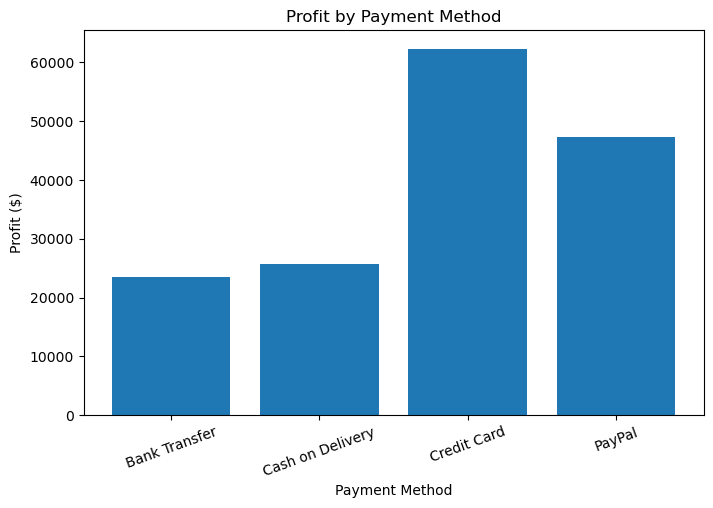

In [94]:
plt.figure(figsize=(8,5))

plt.bar(
    payment_analysis['payment_method'],
    payment_analysis['profit']
)

plt.title("Profit by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Profit ($)")
plt.xticks(rotation=20)

plt.show()

In [95]:
#quantity vs profit(does selling more items increase profit)
quantity_profit = (
    df.groupby('quantity')['profit']
      .mean()
      .reset_index()
)

quantity_profit

,quantity,profit
0,1,15.57
1,2,41.50
2,3,59.65
3,4,84.78
4,5,116.97
5,6,148.76
6,7,177.01
7,8,190.39
8,9,190.62
9,10,332.65


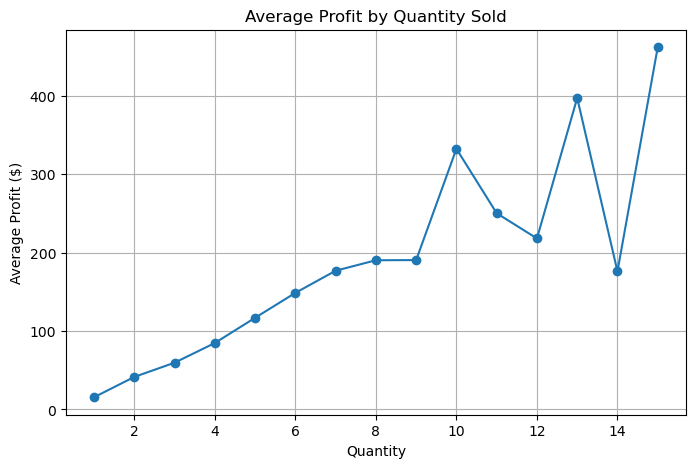

In [96]:
plt.figure(figsize=(8,5))

plt.plot(
    quantity_profit['quantity'],
    quantity_profit['profit'],
    marker='o'
)

plt.title("Average Profit by Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Average Profit ($)")
plt.grid(True)

plt.show()

In [98]:
#Earlier we noticed the minimum profit was -11.28, meaning some transactions lost money. Let's investigate.
#How many are there?
loss_orders = df[df['profit'] < 0]

loss_orders

,order_id,order_date,customer_name,customer_segment,country,region,product_category,product_name,quantity,unit_price,discount_percent,total_sales,shipping_cost,profit,payment_method,year,month,month_number,quarter,profit_margin,cost
11,ORD-11499,2023-01-08,Kenji Rossi,Corporate,Spain,Europe,Office Supplies,Paper Clips Box 500pc,3,7.80,10,21.06,12.61,-2.08,Cash on Delivery,2023,January,1,1,-9.88,23.14
14,ORD-10793,2023-01-13,Zara Brown,Corporate,Italy,Europe,Office Supplies,Tape Dispenser Heavy Duty,1,15.82,0,15.82,9.16,-0.46,PayPal,2023,January,1,1,-2.91,16.28
20,ORD-10686,2023-01-15,Clara Smith,Corporate,Colombia,South America,Office Supplies,Whiteboard Markers Set 8,5,9.91,25,37.16,20.73,-5.87,Cash on Delivery,2023,January,1,1,-15.80,43.03
23,ORD-10846,2023-01-17,Yuki Costa,Corporate,UAE,Middle East & Africa,Office Supplies,Sticky Notes Multicolor 6-Pack,2,11.41,5,21.68,15.26,-3.85,Bank Transfer,2023,January,1,1,-17.76,25.53
31,ORD-11723,2023-01-23,Raj Costa,Consumer,United Kingdom,Europe,Office Supplies,Stapler Full-Size,1,8.54,15,7.26,7.97,-4.55,Credit Card,2023,January,1,1,-62.67,11.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1954,ORD-10352,2025-12-08,Chen Patel,Corporate,Nigeria,Middle East & Africa,Office Supplies,Tape Dispenser Heavy Duty,2,13.26,10,23.87,15.22,-3.28,PayPal,2025,December,12,4,-13.74,27.15
1967,ORD-11898,2025-12-15,Xiao Johansson,Home Office,Mexico,North America,Office Supplies,Sticky Notes Multicolor 6-Pack,1,9.32,0,9.32,6.23,-1.10,Cash on Delivery,2025,December,12,4,-11.80,10.42
1968,ORD-10723,2025-12-16,Hanna Martinez,Corporate,Germany,Europe,Office Supplies,Paper Clips Box 500pc,4,6.29,10,22.64,14.16,-2.84,Credit Card,2025,December,12,4,-12.54,25.48
1982,ORD-11286,2025-12-23,Robert Sato,Consumer,Canada,North America,Office Supplies,Ballpoint Pen Pack 12,2,9.45,15,16.06,9.31,-1.76,PayPal,2025,December,12,4,-10.96,17.82


In [99]:
#Which categories?
loss_orders['product_category'].value_counts()

product_category
Office Supplies           224
Clothing & Accessories     23
Technology                 15
Furniture                  10
Name: count, dtype: int64

In [100]:
#Which regions?
loss_orders['region'].value_counts()

region
Asia Pacific            86
North America           56
Europe                  53
Middle East & Africa    39
South America           38
Name: count, dtype: int64

In [101]:
#Highest discounts?
loss_orders[['product_name',
             'discount_percent',
             'total_sales',
             'profit']].sort_values('profit')

,product_name,discount_percent,total_sales,profit
314,Paper Clips Box 500pc,0,6.62,-11.28
1179,Paper Clips Box 500pc,15,4.14,-10.48
1387,Paper Clips Box 500pc,20,2.42,-10.10
53,Paper Clips Box 500pc,10,4.30,-9.69
1544,Whiteboard Markers Set 8,10,6.24,-9.17
...,...,...,...,...
692,Binder Clips Assorted 48pc,15,28.36,-0.08
368,Canvas Messenger Bag,15,29.04,-0.06
1439,Desk Organizer Set,20,46.70,-0.04
1908,Desk Calendar 2025,5,22.80,-0.01


In [102]:
#correlation analysis
correlation = df[
    [
        'quantity',
        'unit_price',
        'discount_percent',
        'total_sales',
        'shipping_cost',
        'profit'
    ]
].corr()

correlation

,quantity,unit_price,discount_percent,total_sales,shipping_cost,profit
quantity,1.00,0.02,0.01,0.50,0.77,0.50
unit_price,0.02,1.00,0.02,0.70,0.02,0.67
discount_percent,0.01,0.02,1.00,-0.05,0.02,-0.14
total_sales,0.50,0.70,-0.05,1.00,0.39,0.98
shipping_cost,0.77,0.02,0.02,0.39,1.00,0.36
profit,0.50,0.67,-0.14,0.98,0.36,1.00


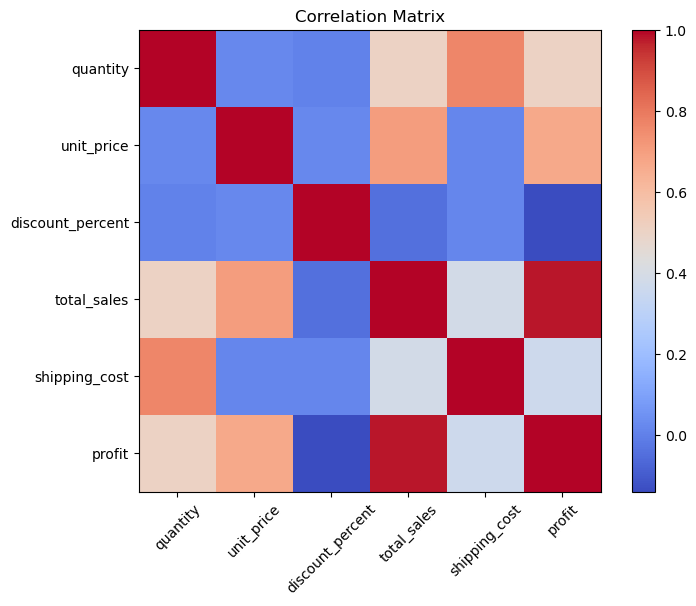

In [103]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap='coolwarm')

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=45)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

In [112]:
#all the analysis in QA 3
discount_analysis
shipping_region
payment_analysis
quantity_profit
loss_orders.shape
loss_orders['product_category'].value_counts()
loss_orders['region'].value_counts()
correlation

,quantity,unit_price,discount_percent,total_sales,shipping_cost,profit
quantity,1.00,0.02,0.01,0.50,0.77,0.50
unit_price,0.02,1.00,0.02,0.70,0.02,0.67
discount_percent,0.01,0.02,1.00,-0.05,0.02,-0.14
total_sales,0.50,0.70,-0.05,1.00,0.39,0.98
shipping_cost,0.77,0.02,0.02,0.39,1.00,0.36
profit,0.50,0.67,-0.14,0.98,0.36,1.00
